# Split Half Analysis Part I:
ANOVA was fitted on one half of the data and Kmeans was fitted on the other half so that the clusters were independently identified. 
Reverse the halves from Part II.

*Yiyu Wang 2025 September*


In [ ]:
from pathlib import Path
import sys

sys.path.insert(0, str(Path.cwd() / "src"))

import glob
import math

import matplotlib
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd
import pingouin as pg
import scipy.stats as stats
import seaborn as sns
from nilearn import plotting, surface
from nilearn.datasets import fetch_surf_fsaverage
from nilearn.glm import threshold_stats_img
from nilearn.image import concat_imgs, load_img, math_img, mean_img, new_img_like
from nilearn.maskers import NiftiLabelsMasker
from nilearn.reporting import get_clusters_table
from scipy.stats import norm
from sklearn.cluster import AgglomerativeClustering, KMeans, MiniBatchKMeans
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import pdist, squareform

from agentprediction import AnalysisConfig
from agentprediction.anova import (
    ANOVA_CONDITIONS,
    create_bar_plots_for_clusters,
    create_cluster_mean_beta,
    create_grouped_barplot,
    find_best_k,
    fit_omnibus_anova,
    plot_knee_curve,
)
from agentprediction.plotting import lighten_color

cluster_colors = ["#FFC800", "#7A3EB1", "#F76800"]
config = AnalysisConfig()
gm_mask_img = config.gm_mask_img


In [ ]:
subjects_list = config.load_subjects()
sample_n = len(subjects_list)
print("subjects in this analysis:")
print(subjects_list)
print(f"**** n = {sample_n} *****")

TR = 0.001
N_TR = config.n_tr
TR_Length = config.tr
TR_IN_MS = int(TR_Length / TR)
fwhm = 0

from sklearn.model_selection import train_test_split
subj_train, subj_test = train_test_split(subjects_list, test_size=0.5, random_state=42)
print("train subjects:")
print(subj_train)
print("test subjects:")
print(subj_test)


In [ ]:
model = 'model_SplitHalf'
beta_dir = str(config.first_level_dir(model)) + "/"
second_level_res_dir = str(config.path(config.results_dir) / model / "omnibus_anova_F") + "/"
Path(second_level_res_dir).mkdir(parents=True, exist_ok=True)

vmax = 5
cluster_thre = 30
p_val = 0.05
p_unc = norm.isf(p_val)
p001 = 0.001
p001_unc = norm.isf(p001)
alpha = 0.05


# Regression model with an omnibus ANOVA design

In [ ]:
anova_results = fit_omnibus_anova(config, model=model, subjects=subj_train)
second_level_input = anova_results["second_level_input"]
X = anova_results["design_matrix"]
second_level_model = anova_results["second_level_model"]
group_res = anova_results["group_res"]
file_list = second_level_input
print(file_list)
print(len(file_list))


In [ ]:
# Shared helpers imported from src/agentprediction/anova.py
column_names = ANOVA_CONDITIONS

def CreateClusterMeanBeta(masker):
    return create_cluster_mean_beta(masker, beta_dir, column_names=column_names)

def CreateBarPlotsForClusters(df, df_err=None, title="", subtitle_list=None, color_list=None, df_sem=None, hatches=None):
    err = df_sem if df_sem is not None else df_err
    return create_bar_plots_for_clusters(df, err, title=title, hatches=hatches, color_list=color_list)


second level threshold: fdr =2.749701713145891
(91, 109, 91, 87)


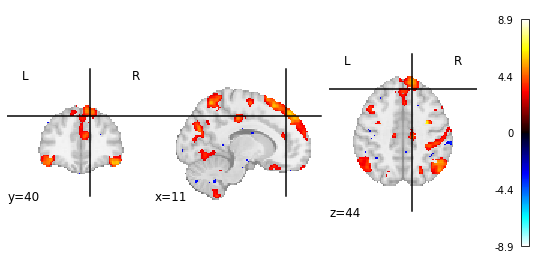

In [69]:


group_res_zscore = nib.load(f'{second_level_res_dir}omnibus_anova_z_score.nii.gz')
gm_mask_img = nib.load('masks/gm_mask_icbm152_brain.nii.gz')
group_res_zscore = math_img('img1 * img2', img1=group_res_zscore, img2=gm_mask_img)

thresholded_map, second_level_threshold = threshold_stats_img(group_res_zscore, 
                                    alpha=0.05,
                                    height_control='fdr')


print(f"second level threshold: fdr ={second_level_threshold}")

plotting.plot_stat_map(thresholded_map)
# save the thresholded map
nib.save(thresholded_map, f'{second_level_res_dir}omnibus_anova_z_score_fdr.nii.gz')
table, label_maps = get_clusters_table(group_res_zscore, stat_threshold=second_level_threshold, cluster_threshold=50, return_label_maps=True)

# create labels masker
masker = NiftiLabelsMasker(label_maps[0], standardize=False)


# run kmeans to further reduce the number of clusters
# run kmeans at the subject level: n ROIs x 6 features x 15 subjects => n x 90 matrix
from nilearn.image import load_img
all_sub_z = load_img(second_level_input) # 91, 109, 91, 180
print(all_sub_z.shape)
roi_sub_z = masker.fit_transform(all_sub_z) # 180 x n clusters

roi_sub_z_df = pd.DataFrame(roi_sub_z)

video_name_list = [f.split("video-")[1].split("_gm_masked.nii")[0] for f in second_level_input]
s_name_list = [f.split("sub-")[1].split("_z")[0] for f in second_level_input]
roi_sub_z_df['sub_video'] = [f"sub-{s}_video-{v}" for s, v in zip(s_name_list, video_name_list)]
roi_sub_z_df['video'] = video_name_list
df_grouped = roi_sub_z_df.groupby('video').mean().T
df_grouped = df_grouped.reset_index(drop=True)





In [70]:
table.to_csv(f'Results/{model}/omnibus_anova_clusters.csv', index=False)

# Figure S6

In [ ]:
X = roi_sub_z_df.iloc[:, 0:-2].T
optimal_k, inertias = plot_knee_curve(X, max_k=12, random_state=42, title="Full Sample")


Optimal number of clusters: 3


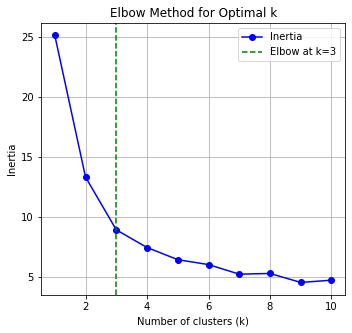

In [72]:
from sklearn.preprocessing import normalize
from sklearn.cluster import MiniBatchKMeans
from kneed import KneeLocator
from sklearn.metrics import silhouette_samples, silhouette_score

X = roi_sub_z_df.iloc[:, 0:-2].T
X_normalized = normalize(X)  # ensures unit-length rows

inertias = []
K = range(1, 11)


for k in K:
    kmeans = MiniBatchKMeans(n_clusters=k, random_state=0)
    kmeans.fit(X_normalized)
    inertias.append(kmeans.inertia_)
    

# Find the "elbow" point by taking two derivatives
inertia_diff = np.diff(inertias)  # First derivative
inertia_diff2 = np.diff(inertia_diff)  # Second derivative
elbow_k = np.argmax(inertia_diff2) + 3  # Adding 3 because we took two derivatives

# Plotting the Elbow method
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(K, inertias, 'bo-', label='Inertia')
plt.axvline(x=elbow_k, color='g', linestyle='--', label=f'Elbow at k={elbow_k}')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.legend()

# Print the optimal number of clusters
print(f"Optimal number of clusters: {elbow_k}")


In [73]:
X = roi_sub_z_df.iloc[:, 0:-2].T

from sklearn_extra.cluster import KMedoids

# make consine distance
X_normalized = normalize(X)  # now cosine distance ~ euclidean on unit sphere

model = MiniBatchKMeans(n_clusters=3, random_state=42)
cluster_labels = model.fit_predict(X_normalized)


cluster_labels = cluster_labels + 1
print(cluster_labels)


# # for visualization, change cluster label 1 to 3, 2 to 1, and 3 to 2
cluster_labels = np.where(cluster_labels == 1, 4, cluster_labels)
cluster_labels = np.where(cluster_labels == 2, 1, cluster_labels)
cluster_labels = np.where(cluster_labels == 3, 2, cluster_labels)
cluster_labels = np.where(cluster_labels == 4, 3, cluster_labels)
print(cluster_labels)

df_grouped['Cluster'] = cluster_labels


[2 2 2 1 2 3 2 3 1 2 2 1 1 2 2 2 2 3 2 1 1 3 3 3 2 1 1 2 3 3 3 2 2]
[1 1 1 3 1 2 1 2 3 1 1 3 3 1 1 1 1 2 1 3 3 2 2 2 1 3 3 1 2 2 2 1 1]


In [74]:
# # drop column 11 (which is roi #12) for roi_sub_z_df because it is not a valid gray matter roi upon visual inspection
# roi_sub_z_df.drop(columns=[11], inplace=True)
# # remove row 11 for df_grouped
# df_grouped.drop(index=11, inplace=True)

In [75]:



# change the masker
# after review, removing brain region 12 that is not a valid cluster
label_map = label_maps[0]
label_map_data = label_map.get_fdata()
# label_map_data[label_map_data == 12] = 0  # set the label to 0


# # shift the later brain region numbers up
# for i in range(13, 32 + 1):
#     label_map_data[label_map_data == i] = i - 1  # shift the label up by 1


# save the updated label map
new_label_map = new_img_like(label_map, label_map_data)

# create new masker
masker = NiftiLabelsMasker(new_label_map, standardize=False).fit()

cluster_labels_img = masker.inverse_transform(cluster_labels)
# save the cluster labels image


In [76]:
df_grouped_transposed = roi_sub_z_df.T
df_grouped_transposed.columns = df_grouped_transposed.iloc[-2]
df_grouped_transposed.drop(df_grouped_transposed.tail(2).index, inplace = True)
df_grouped_transposed['Cluster'] = df_grouped['Cluster']

df_grouped_transposed.groupby('Cluster').count()

sub_video,sub-170_video-obs_Pattern,sub-179_video-obs_Pattern,sub-154_video-obs_Pattern,sub-157_video-obs_Pattern,sub-158_video-obs_Pattern,sub-185_video-obs_Pattern,sub-171_video-obs_Pattern,sub-147_video-obs_Pattern,sub-156_video-obs_Pattern,sub-160_video-obs_Pattern,...,sub-158_video-fb_Pattern_PE,sub-185_video-fb_Pattern_PE,sub-171_video-fb_Pattern_PE,sub-147_video-fb_Pattern_PE,sub-156_video-fb_Pattern_PE,sub-160_video-fb_Pattern_PE,sub-174_video-fb_Pattern_PE,sub-146_video-fb_Pattern_PE,sub-166_video-fb_Pattern_PE,sub-159_video-fb_Pattern_PE
Cluster,,,,,,,,,,,,,,,,,,,,,
1,16,16,16,16,16,16,16,16,16,16,...,16,16,16,16,16,16,16,16,16,16
2,9,9,9,9,9,9,9,9,9,9,...,9,9,9,9,9,9,9,9,9,9
3,8,8,8,8,8,8,8,8,8,8,...,8,8,8,8,8,8,8,8,8,8


In [77]:
data = roi_sub_z_df.copy()
cluster_dict = pd.DataFrame({'brain_region': [f'brain_region_{i}' for i in range(1, len(df_grouped_transposed)+1)], 'cluster': df_grouped['Cluster']})
# drop the video_column
data = data.drop(columns=['sub_video'])

data.columns = [f'brain_region_{i}' for i in range(1, len(df_grouped_transposed)+1)] + ['trial']



data['condition'] = data['trial'].str.split('_', expand=True)[1]
# rename condition to Social = agent-dependent, Pattern = agent-independent
data.loc[data['condition']=='Social', 'condition'] = 'agent-dependent'
data.loc[data['condition']=='Pattern', 'condition'] = 'agent-independent'
data['video'] = data['trial'].str.split('_', expand=True)[0]
data['PE'] = data['trial'].str.split('_', expand=True)[2]
data.loc[data['video']=='obs', 'PE'] = 'obs'
# drop video column and name PE column as video
data = data.drop(columns=['video'])
data = data.rename(columns={'PE':'video'})


In [78]:
# # manual labeling of clusters outside this script before running the rest of the code
# roi_name_df = pd.read_csv(f'{second_level_res_dir}cluster_table_annotated.csv')
# roi_name_df

In [79]:
roi_name_df = table.copy()
roi_name_df['roi_name'] = roi_name_df["Cluster ID"]

In [80]:
roi_name_df.rename(columns={'Cluster ID':'brain_region'}, inplace=True)
roi_name_df['brain_region'] = roi_name_df['brain_region'].apply(lambda x: f"brain_region_{x}")


roi_name_df

,brain_region,X,Y,Z,Peak Stat,Cluster Size (mm3),roi_name
0,brain_region_1,28.0,-8.0,52.0,8.880526,6416,1
1,brain_region_1a,16.0,-8.0,62.0,5.516850,,1a
2,brain_region_2,-24.0,-10.0,58.0,7.704772,6168,2
3,brain_region_2a,-40.0,-8.0,54.0,5.897691,,2a
4,brain_region_3,-24.0,-60.0,60.0,7.564911,8024,3
...,...,...,...,...,...,...,...
79,brain_region_29,-66.0,-30.0,-12.0,4.081549,632,29
80,brain_region_30,-44.0,14.0,44.0,4.021184,792,30
81,brain_region_31,46.0,44.0,22.0,3.895113,480,31
82,brain_region_32,48.0,-68.0,0.0,3.870964,952,32


# Figure S5:

## Important: The ROI number on the plot does not match the ROI number in the cluster table. 
Need an mapping like: plot_to_table_roi_number = dict(enumerate(brain_regions, start=1))

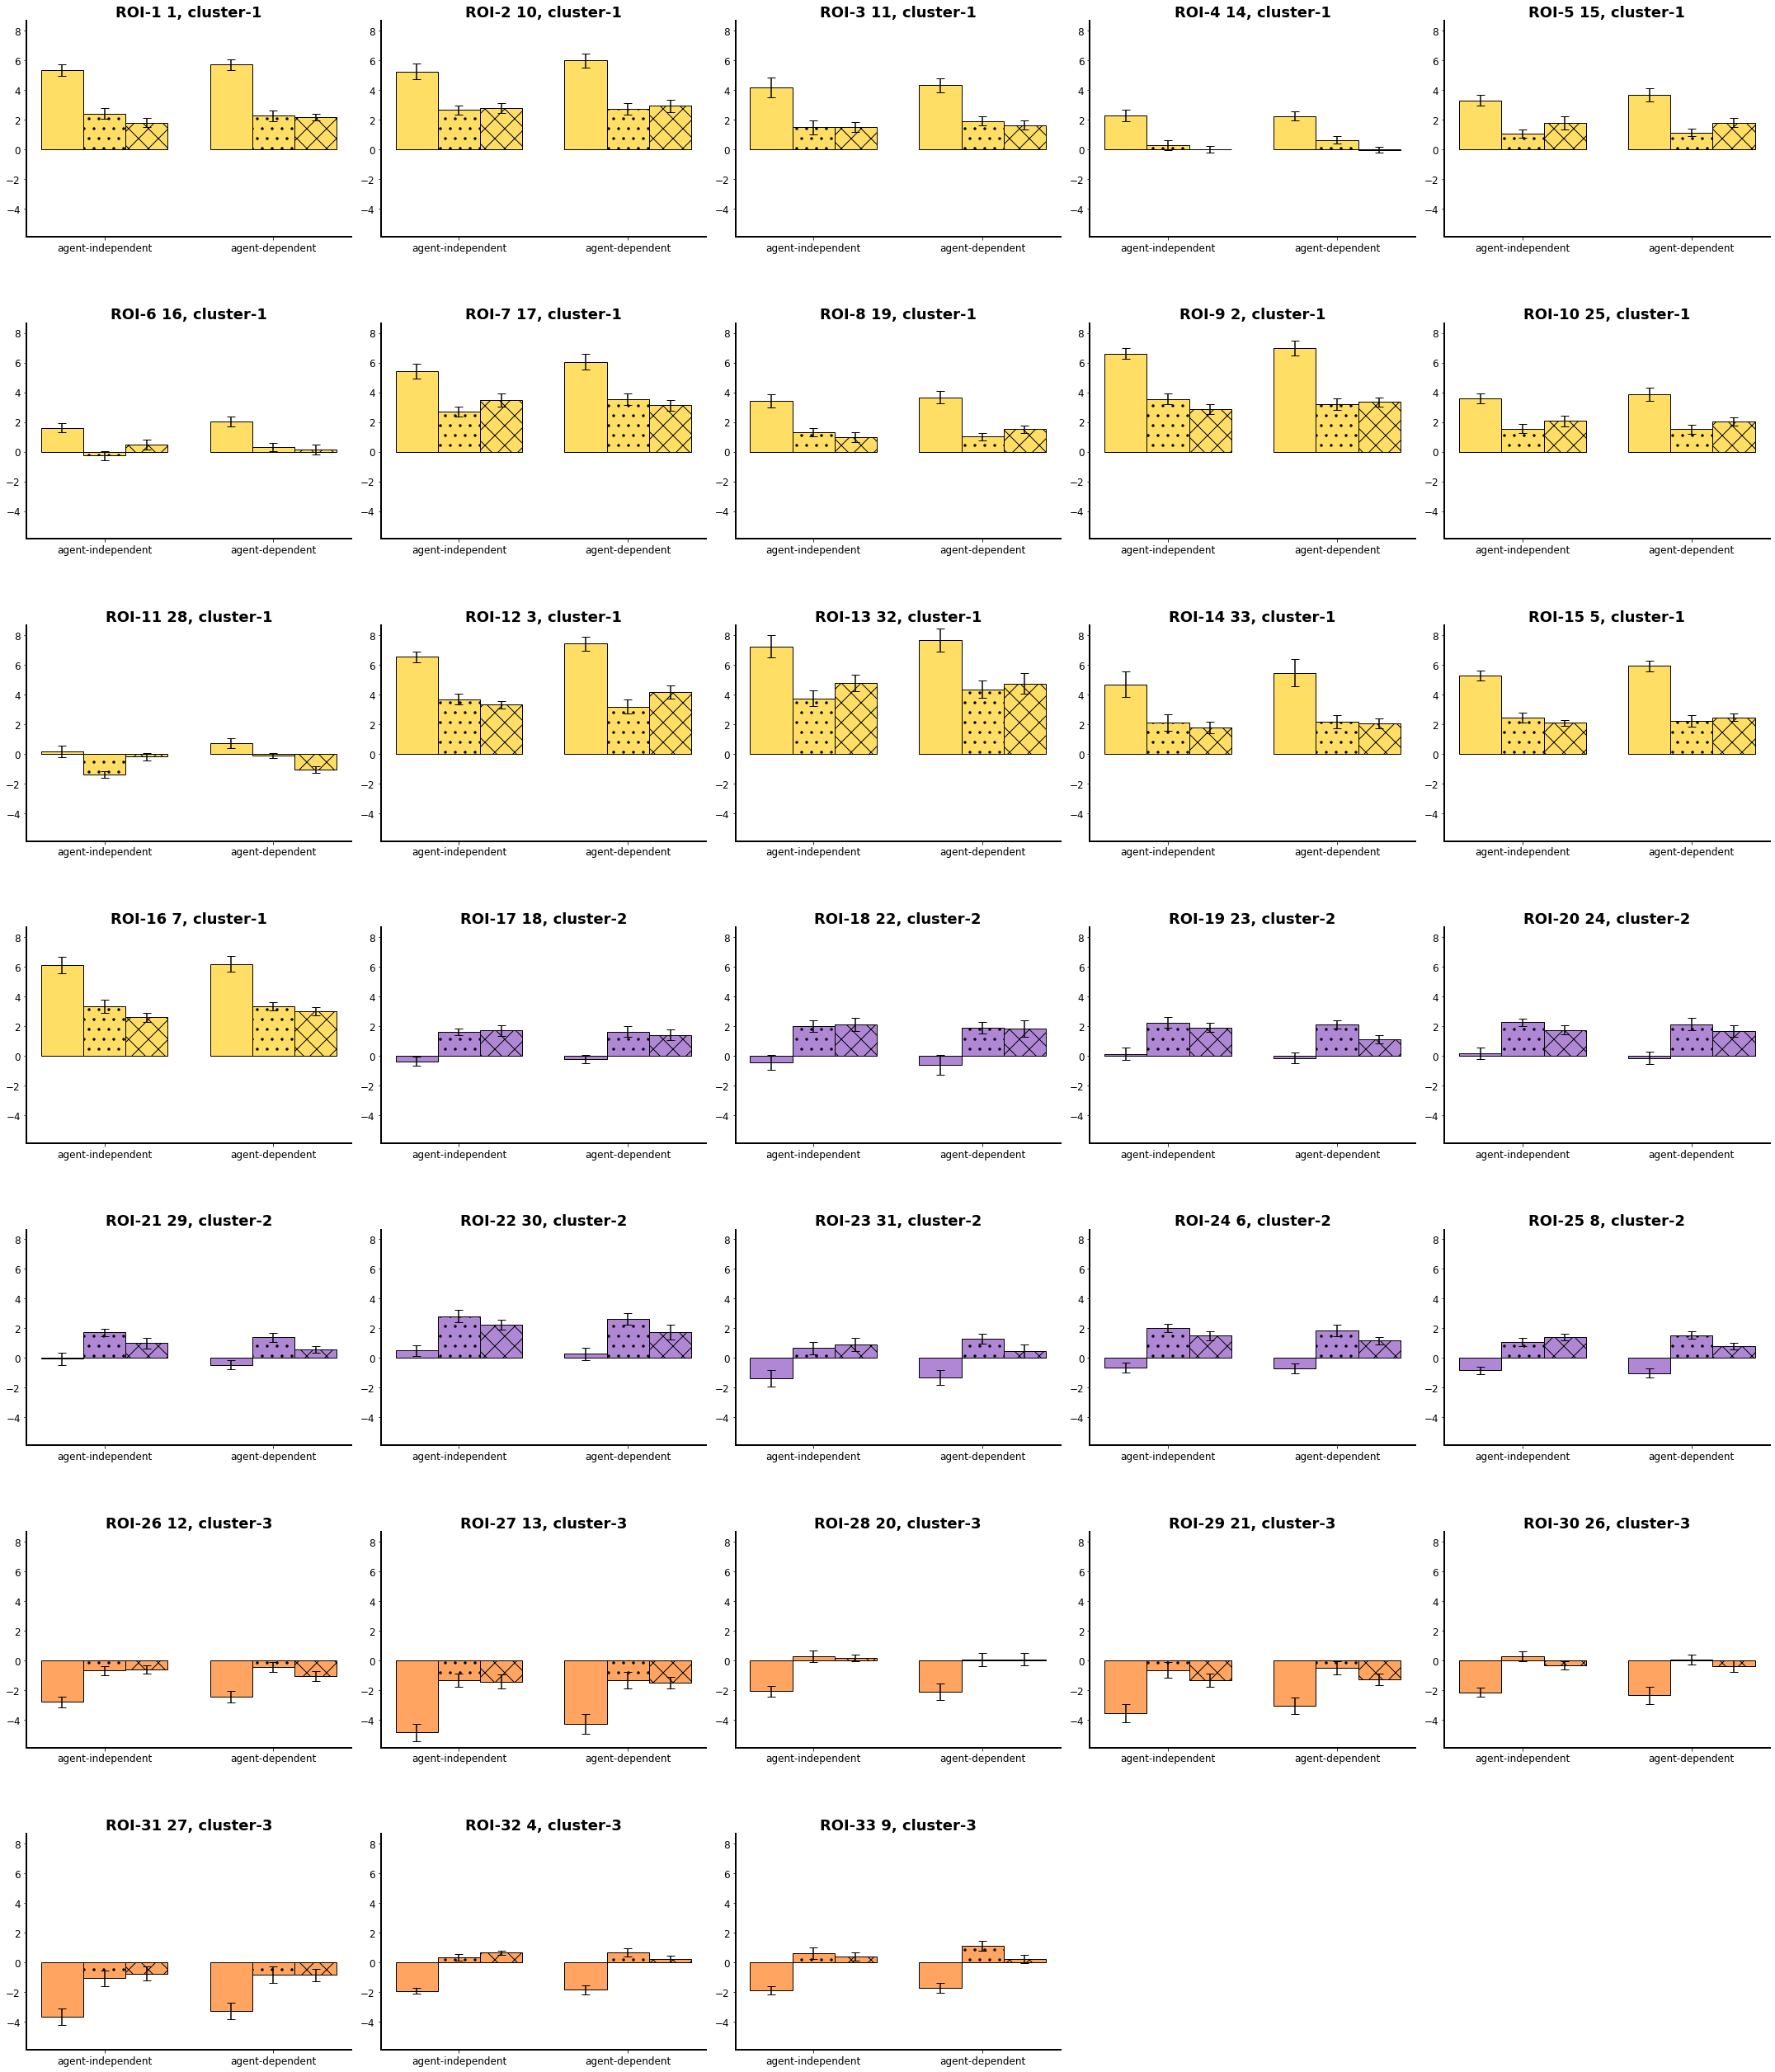

In [81]:

cluster_colors_dict = {
     '1': '#FFC800', '2': '#7A3EB1', '3': '#F76800'} 

region_to_name = roi_name_df.set_index("brain_region")["roi_name"].to_dict()

metadata_cols = ['condition', 'video', 'trial']
brain_regions = [col for col in data.columns if col not in metadata_cols]

n_regions = len(brain_regions)
n_cols = min(n_regions, 5)
n_rows = int(np.ceil(n_regions / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
axes = axes.ravel()


# map brain region to cluster
region_to_cluster = cluster_dict.set_index("brain_region")["cluster"].to_dict()

# Sort brain regions based on cluster number (regions without a cluster go to the end)
brain_regions = sorted(
    [col for col in data.columns if col not in metadata_cols],
    key=lambda region: (region_to_cluster.get(region, float('inf')), region)
)


feedback_types = ['obs', 'Congruent', 'PE']
width = 0.25

# Compute global y-limits
all_values, all_sems = [], []
for region in brain_regions:
    for fb in feedback_types:
        for cond in data['condition'].unique():
            subset = data[(data['condition'] == cond) & (data['video'] == fb)]
            all_values.append(subset[region].mean())
            all_sems.append(subset[region].sem())
max_value = max(all_values) + max(all_sems) + 0.1
min_value = min(all_values) - max(all_sems) - 0.1

for idx, region in enumerate(brain_regions):
    ax = axes[idx]

    region_name = region_to_name.get(region, 'Unknown')
    cluster = region_to_cluster.get(region, 'Unknown')

    base_color = cluster_colors_dict.get(str(cluster), '#999999')
    light_color = lighten_color(base_color, 0.6)
    

    conditions = data['condition'].unique()
    x = np.arange(len(conditions))

    for i, fb_type in enumerate(feedback_types):
        means, sems = [], []
        for cond in conditions:
            subset = data[(data['condition'] == cond) & (data['video'] == fb_type)]
            means.append(subset[region].mean())
            sems.append(subset[region].sem())

        if fb_type == 'obs':
            color = light_color
            hatch = ''
        elif fb_type == 'PE':
            color = light_color
            hatch = 'x'
        else:
            color = light_color
            hatch = '.'

        ax.bar(x + (i-1)*width, means, width, 
                label=fb_type, color=color, hatch=hatch,
                yerr=sems, capsize=5, edgecolor='black', linewidth=1)
        


    ax.set_title(f'ROI-{idx+1} {region_name}, cluster-{cluster}', fontsize=18, pad=5, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(conditions, fontsize=14)
    ax.tick_params(axis='both', labelsize=12)
    ax.set_ylim([min_value, max_value])
    ax.spines['left'].set_linewidth(2)
    ax.spines['bottom'].set_linewidth(2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Hide unused subplots
for j in range(len(brain_regions), len(axes)):
    fig.delaxes(axes[j])

fig.tight_layout()
fig.subplots_adjust(hspace=0.4)

In [82]:
roi_sub_z_df_cluster = df_grouped_transposed.groupby('Cluster').mean()
roi_sub_z_df_cluster

sub_video,sub-170_video-obs_Pattern,sub-179_video-obs_Pattern,sub-154_video-obs_Pattern,sub-157_video-obs_Pattern,sub-158_video-obs_Pattern,sub-185_video-obs_Pattern,sub-171_video-obs_Pattern,sub-147_video-obs_Pattern,sub-156_video-obs_Pattern,sub-160_video-obs_Pattern,...,sub-158_video-fb_Pattern_PE,sub-185_video-fb_Pattern_PE,sub-171_video-fb_Pattern_PE,sub-147_video-fb_Pattern_PE,sub-156_video-fb_Pattern_PE,sub-160_video-fb_Pattern_PE,sub-174_video-fb_Pattern_PE,sub-146_video-fb_Pattern_PE,sub-166_video-fb_Pattern_PE,sub-159_video-fb_Pattern_PE
Cluster,,,,,,,,,,,,,,,,,,,,,
1,5.448689,4.817492,5.148329,6.147057,5.568310,3.254786,2.512923,4.324111,4.092422,2.219904,...,2.623445,2.771281,0.775660,0.575877,2.510779,1.585073,1.705877,1.874963,2.970370,2.477974
2,-0.459924,0.704062,-1.008441,0.809380,-0.335154,-2.271334,-1.231035,-0.070947,0.608174,-2.509321,...,2.584321,2.252211,0.403315,0.188194,1.636569,1.550687,1.412697,2.262336,2.627306,2.305022
3,-3.089022,-2.523084,-3.306904,-2.990769,-2.816790,-4.352653,-4.906368,-2.584011,-3.186323,-4.670456,...,0.861824,-1.650285,-1.562532,-1.681663,-0.283813,-1.301388,0.368988,0.514358,0.513974,-0.359252


## run cluster level statistics between the six conditions

In [83]:

import pingouin as pg

cue_cols = [col for col in df_grouped_transposed.columns if 'obs_' in col]
fb_cols = [col for col in df_grouped_transposed.columns if 'fb_' in col]
roi_sub_z_df_cue = roi_sub_z_df_cluster[cue_cols]
roi_sub_z_df_fb = roi_sub_z_df_cluster[fb_cols]

# average social pattern cue videos such that the df is 3x30
sub_id_list = [col.split('sub-')[1].split("_video")[0] for col in roi_sub_z_df_cue.columns]
sub_id_list = ['sub-' + str(sub_id) for sub_id in sub_id_list]
roi_sub_z_df_cue = roi_sub_z_df_cue.T.reset_index(drop=True)
roi_sub_z_df_cue['sub'] = sub_id_list
roi_sub_z_df_cue = roi_sub_z_df_cue.groupby('sub').mean().T

# average Congruent and PE fb videos such that the df is 3x30
sub_id_list = [col.split('sub-')[1].split("_video")[0] for col in roi_sub_z_df_fb.columns]
sub_id_list = ['sub-' + str(sub_id) for sub_id in sub_id_list]
roi_sub_z_df_fb = roi_sub_z_df_fb.T.reset_index(drop=True)
roi_sub_z_df_fb['sub'] = sub_id_list
roi_sub_z_df_fb = roi_sub_z_df_fb.groupby('sub').mean().T


for cluster in roi_sub_z_df_cluster.index:
    cue_values = roi_sub_z_df_cue.loc[cluster].values
    fb_values = roi_sub_z_df_fb.loc[cluster].values
    
    # Perform the t-test
    t_test_result = pg.ttest(cue_values, fb_values, paired=True)
    pg.print_table(t_test_result)

     T    dof  alternative      p-val  CI95%          cohen-d         BF10    power
------  -----  -------------  -------  -----------  ---------  -----------  -------
12.370     14  two-sided        0.000  [2.18 3.09]      2.959  1758000.000    1.000

     T    dof  alternative      p-val  CI95%            cohen-d       BF10    power
------  -----  -------------  -------  -------------  ---------  ---------  -------
-7.884     14  two-sided        0.000  [-2.55 -1.46]      2.224  11300.000    1.000

     T    dof  alternative      p-val  CI95%            cohen-d       BF10    power
------  -----  -------------  -------  -------------  ---------  ---------  -------
-8.723     14  two-sided        0.000  [-2.94 -1.78]      2.209  33130.000    1.000



In [84]:
# select cue video columns
cue_pattern_cols = [col for col in df_grouped_transposed.columns if 'obs_Pattern' in col]
cue_social_cols = [col for col in df_grouped_transposed.columns if 'obs_Social' in col]
cue_pattern_df = roi_sub_z_df_cluster[cue_pattern_cols]
cue_social_df = roi_sub_z_df_cluster[cue_social_cols]
cue_social_df

sub_video,sub-170_video-obs_Social,sub-179_video-obs_Social,sub-154_video-obs_Social,sub-157_video-obs_Social,sub-158_video-obs_Social,sub-185_video-obs_Social,sub-171_video-obs_Social,sub-147_video-obs_Social,sub-156_video-obs_Social,sub-160_video-obs_Social,sub-174_video-obs_Social,sub-143_video-obs_Social,sub-146_video-obs_Social,sub-166_video-obs_Social,sub-159_video-obs_Social
Cluster,,,,,,,,,,,,,,,
1,5.882974,5.779026,5.605638,5.478971,5.334340,3.905364,3.508638,2.489103,5.730691,2.847324,5.139409,3.862286,5.690614,5.951650,5.787419
2,-1.341709,1.157021,-2.223090,0.164197,-0.652186,-2.039505,-1.749267,0.174104,0.878788,-1.499102,0.620278,-0.455159,-1.162361,1.184626,-0.226895
3,-3.727243,-2.410337,-3.722553,-2.488974,-3.134546,-4.851875,-4.428765,-1.974413,-3.104170,-2.178194,-0.576544,-1.115996,-4.075042,-1.283735,-0.573215


In [85]:
# for each cluster, test whether there is a significant difference between the pattern and social conditions


for cluster in roi_sub_z_df_cluster.index:
    pattern_values = cue_pattern_df.loc[cluster].values
    social_values = cue_social_df.loc[cluster].values
    
    # Perform the t-test
    t_test_result = pg.ttest(pattern_values, social_values, paired=True)
    
    pg.print_table(t_test_result) 

     T    dof  alternative      p-val  CI95%            cohen-d    BF10    power
------  -----  -------------  -------  -------------  ---------  ------  -------
-2.012     14  two-sided        0.064  [-0.88  0.03]      0.362   1.274    0.257

    T    dof  alternative      p-val  CI95%            cohen-d    BF10    power
-----  -----  -------------  -------  -------------  ---------  ------  -------
0.780     14  two-sided        0.449  [-0.28  0.6 ]      0.140   0.342    0.080

     T    dof  alternative      p-val  CI95%            cohen-d    BF10    power
------  -----  -------------  -------  -------------  ---------  ------  -------
-0.970     14  two-sided        0.349  [-0.74  0.28]      0.181   0.393    0.100



In [86]:
fd_cols = [col for col in df_grouped_transposed.columns if 'fb_' in col]
fb_df = roi_sub_z_df_cluster[fd_cols]

df_groupd = fb_df.groupby('Cluster').mean()
sub_id_list = [col.split('sub-')[1].split("_video")[0] for col in df_groupd.columns]
sub_id_list = ['sub-' + str(sub_id) for sub_id in sub_id_list]
df_groupd.columns = [col.split('video-')[1] for col in df_groupd.columns]
df_groupd = df_groupd.T.reset_index()
df_groupd.columns = ['trial'] + [f'Cluster-{i}' for i in roi_sub_z_df_cluster.index]
df_groupd['condition'] = df_groupd['trial'].str.split('_', expand=True)[1]
# rename condition to Social = agent-dependent, Pattern = agent-independent/
df_groupd.loc[df_groupd['condition']=='Social', 'condition'] = 'agent-dependent'
df_groupd.loc[df_groupd['condition']=='Pattern', 'condition'] = 'agent-independent'
df_groupd['feedback_type'] = df_groupd['trial'].str.split('_', expand=True)[0]
df_groupd['PE'] = df_groupd['trial'].str.split('_', expand=True)[2]
df_groupd.loc[df_groupd['feedback_type']=='obs', 'PE'] = 'obs'
# drop video column and name PE column as video
df_groupd = df_groupd.drop(columns=['feedback_type'])
df_groupd = df_groupd.rename(columns={'PE':'feedback_type'})
df_groupd['subject']=sub_id_list
df_groupd

,trial,Cluster-1,Cluster-2,Cluster-3,condition,feedback_type,subject
0,fb_Social_Congruent,3.039486,2.202175,-0.694703,agent-dependent,Congruent,sub-170
1,fb_Social_Congruent,3.294387,2.354275,-0.555514,agent-dependent,Congruent,sub-179
2,fb_Social_Congruent,2.598196,0.684515,-0.127325,agent-dependent,Congruent,sub-154
3,fb_Social_Congruent,2.260229,1.067659,0.051645,agent-dependent,Congruent,sub-157
4,fb_Social_Congruent,2.314931,3.363733,1.392662,agent-dependent,Congruent,sub-158
5,fb_Social_Congruent,1.667072,2.255679,-1.233187,agent-dependent,Congruent,sub-185
6,fb_Social_Congruent,0.181487,0.425578,-1.205911,agent-dependent,Congruent,sub-147
7,fb_Social_Congruent,1.788470,2.264058,0.385416,agent-dependent,Congruent,sub-156
8,fb_Social_Congruent,2.176969,0.603757,-2.403922,agent-dependent,Congruent,sub-160
9,fb_Social_Congruent,1.616873,2.819165,1.904225,agent-dependent,Congruent,sub-174


In [87]:

for i in roi_sub_z_df_cluster.index:
    aov = pg.rm_anova(dv=f'Cluster-{i}', within=['condition', 'feedback_type'],
                    subject='subject', data=df_groupd)
    pg.print_table(aov)
 


ANOVA SUMMARY

Source                        SS    ddof1    ddof2     MS      F    p-unc    p-GG-corr    ng2    eps
-------------------------  -----  -------  -------  -----  -----  -------  -----------  -----  -----
condition                  0.107        1       11  0.107  0.583    0.461        0.461  0.004  1.000
feedback_type              0.053        1       11  0.053  0.082    0.780        0.780  0.002  1.000
condition * feedback_type  0.012        1       11  0.012  0.064    0.804        0.804  0.000  1.000


ANOVA SUMMARY

Source                        SS    ddof1    ddof2     MS      F    p-unc    p-GG-corr    ng2    eps
-------------------------  -----  -------  -------  -----  -----  -------  -----------  -----  -----
condition                  1.055        1       11  1.055  1.755    0.212        0.212  0.027  1.000
feedback_type              2.003        1       11  2.003  7.744    0.018        0.018  0.051  1.000
condition * feedback_type  0.273        1       11  0.273 

# Figure 2a

In [88]:
# make surface objects

overlay = cluster_labels_img
for i in range(1, 4):
    nib.save(math_img(f'img1 == {i}', img1=overlay), f'{second_level_res_dir}cluster_{i}.nii.gz')


In [89]:
from nilearn.datasets import fetch_surf_fsaverage
from nilearn import surface

fsaverage = fetch_surf_fsaverage()

overlay = cluster_labels_img
# make bar plots for each cluster

for cluster in df_grouped_transposed['Cluster'].unique():
    cluster_df = df_grouped_transposed[df_grouped_transposed['Cluster']==cluster]
    
    for video in ['obs_Pattern', 'obs_Social', 'fb_Pattern_PE', 'fb_Social_PE', 'fb_Pattern_Congruent', 'fb_Social_Congruent']:
        video_df = cluster_df[cluster_df.columns[cluster_df.columns.str.contains(video)]]
        

# since suface rendering is a probablistic interpolation, set a threshold for binarizing:
texture_threshold = 0.5

# Binarize the img for groups 1 to 3
groups = [math_img(f'img1 == {i}', img1=overlay) for i in range(1, 4)]

surfaces = [fsaverage.pial_right, fsaverage.pial_left]

# Process each group
textures = {}
for i, group in enumerate(groups, start=1):
    textures[f'right{i}'], textures[f'left{i}'] = [
        np.where(surface.vol_to_surf(group, surf, interpolation='nearest') > texture_threshold, i, 0)
        for surf in surfaces
    ]

sum_texture_right = sum(textures[f'right{i}'] for i in range(1, 4))
sum_texture_left = sum(textures[f'left{i}'] for i in range(1, 4))    


group 1
group 2
group 3


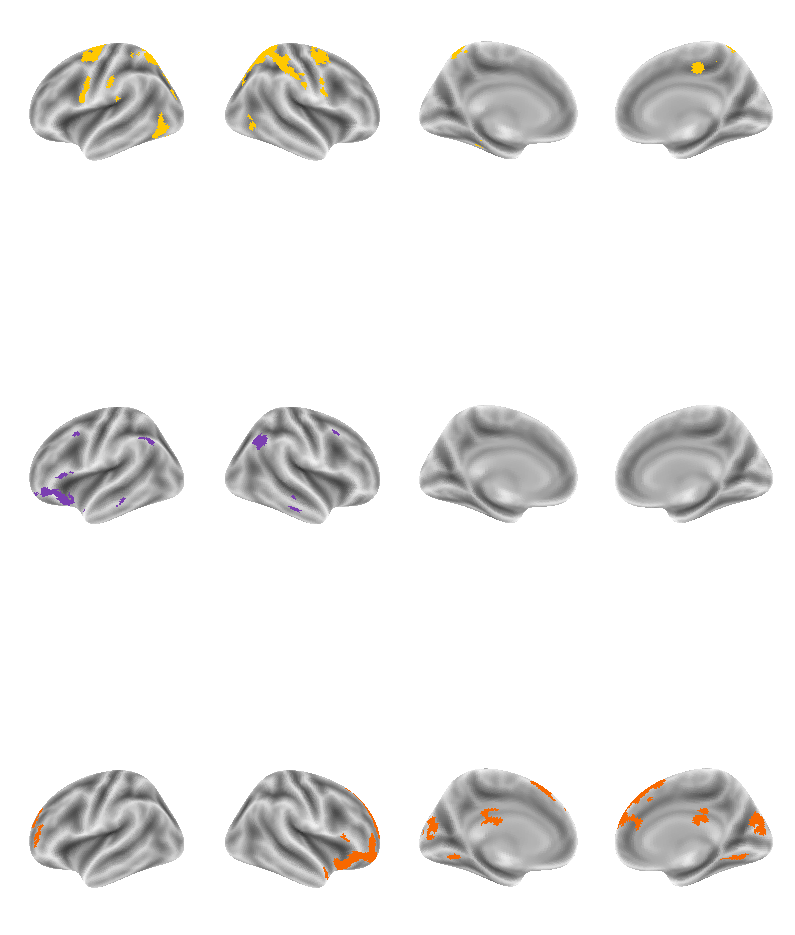

In [90]:
import matplotlib
# since suface rendering is a probablistic interpolation, set a threshold for binarizing:
texture_threshold = 0.5
threshold =0.01

# Binarize the img for groups 1 to 4
groups = [math_img(f'img1 == {i}', img1=overlay) for i in range(1, 4)]

surfaces = [fsaverage.pial_right, fsaverage.pial_left]

# Process each group
textures = {}
for i, group in enumerate(groups, start=1):
    print(f'group {i}')
    textures[f'right{i}'], textures[f'left{i}'] = [
        np.where(surface.vol_to_surf(group, surf, interpolation='nearest') > texture_threshold, 1, 0)
        for surf in surfaces
    ]

vmin = 0

vmax = 3
my_cmap = matplotlib.colors.ListedColormap(cluster_colors)

# Create a 4x4 subplot layout for each group
fig, axes = plt.subplots(nrows=vmax, ncols=4, figsize=(14, 20), subplot_kw={'projection': '3d'})

# make axes tighter
plt.subplots_adjust(wspace=0.01, hspace=0.01)
# Iterate over each group and plot left & right hemispheres
for i in range(1, vmax+1):
    plotting.plot_surf(
        fsaverage.infl_left, textures[f'left{i}'], view='lateral', hemi='left',
        colorbar=False, cmap=matplotlib.colors.ListedColormap(['#FFFFFF', cluster_colors[i-1]]), threshold=threshold, vmin=0, vmax=1,
        avg_method='median', cbar_vmin=0, cbar_vmax=3,
        bg_map=fsaverage.sulc_left, axes=axes[i-1, 0], darkness=0.8, inflate=True
    )

    plotting.plot_surf(
        fsaverage.infl_right, textures[f'right{i}'], view='lateral', hemi='right',
        colorbar=False, cmap=matplotlib.colors.ListedColormap(['#FFFFFF', cluster_colors[i-1]]), threshold=threshold, vmin=0, vmax=1,
        avg_method='median', cbar_vmin=0, cbar_vmax=3,
        bg_map=fsaverage.sulc_right, axes=axes[i-1, 1], darkness=0.8, inflate=True
    )
    
    plotting.plot_surf(
        fsaverage.infl_left, textures[f'left{i}'], view='medial', hemi='left',
        colorbar=False, cmap=matplotlib.colors.ListedColormap(['#FFFFFF', cluster_colors[i-1]]), threshold=threshold, vmin=0, vmax=1,
        avg_method='median', cbar_vmin=0, cbar_vmax=3,
        bg_map=fsaverage.sulc_left, axes=axes[i-1, 2], darkness=0.8, inflate=True
    )

    plotting.plot_surf(
        fsaverage.infl_right, textures[f'right{i}'], view='medial', hemi='right',
        colorbar=False, cmap=matplotlib.colors.ListedColormap(['#FFFFFF', cluster_colors[i-1]]), threshold=threshold, vmin=0, vmax=1,
        avg_method='median', cbar_vmin=0, cbar_vmax=3,
        bg_map=fsaverage.sulc_right, axes=axes[i-1, 3], darkness=0.8, inflate=True
    )



plt.show()


<AxesSubplot:>

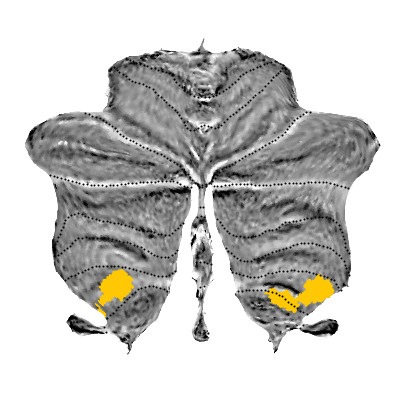

In [91]:
# make cerebellum plot for cluster group 1
import SUITPy.flatmap as flatmap
import matplotlib.colors as mcolors
import matplotlib.cm as cm
overlay_group1 = math_img('img == 1', img=overlay)
# make cmap based on the cluster colors
# Define the color
hex_color = cluster_colors[0]
# Convert to RGB
rgb_color = mcolors.hex2color(hex_color)
# Create a colormap from a single color
cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", [(0, rgb_color), (1, rgb_color)])

funcdata = flatmap.vol_to_surf(overlay_group1,space='MNISymC')
# binarize funcdata if > 0.2
funcdata[funcdata>=0.2] = 1
funcdata[funcdata<0.2] = 0
# Make gifti image with the right column names
flatmap.plot(data=funcdata, cmap=cmap, \
    threshold=0.02, \
    new_figure=True, \
    colorbar=False, \
    render='matplotlib')


<AxesSubplot:>

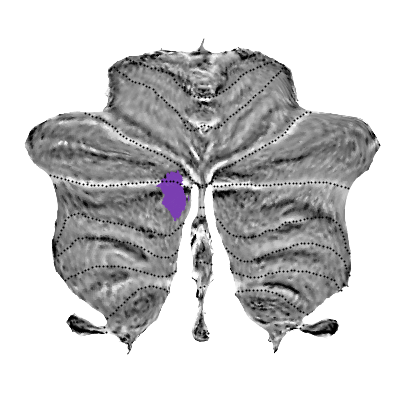

In [92]:
# make cerebellum plot for cluster group 2
import SUITPy.flatmap as flatmap
import matplotlib.colors as mcolors
import matplotlib.cm as cm
overlay_group2 = math_img('img == 2', img=overlay)
# make cmap based on the cluster colors
hex_color = cluster_colors[1]
rgb_color = mcolors.hex2color(hex_color)
cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", [(0, rgb_color), (1, rgb_color)])

funcdata = flatmap.vol_to_surf(overlay_group2,space='MNISymC')
# binarize funcdata if > 0.2
funcdata[funcdata>=0.2] = 1
funcdata[funcdata<0.2] = 0
# Make gifti image with the right column names
flatmap.plot(data=funcdata, cmap=cmap, \
    threshold=0.02, \
    new_figure=True, \
    colorbar=False, \
    render='matplotlib')


<AxesSubplot:>

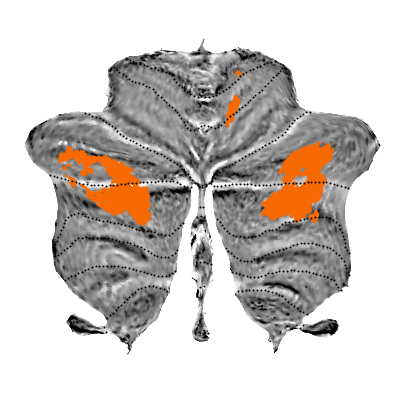

In [93]:
# make cerebellum plot for cluster group 3
import SUITPy.flatmap as flatmap
import matplotlib.colors as mcolors
import matplotlib.cm as cm
overlay_group3 = math_img('img == 3', img=overlay)
# make cmap based on the cluster colors
hex_color = cluster_colors[2]
rgb_color = mcolors.hex2color(hex_color)
cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", [(0, rgb_color), (1, rgb_color)])

funcdata = flatmap.vol_to_surf(overlay_group3,space='MNISymC')
# binarize funcdata if > 0.2
funcdata[funcdata>=0.2] = 1
funcdata[funcdata<0.2] = 0
# Make gifti image with the right column names
flatmap.plot(data=funcdata, cmap=cmap, \
    threshold=0.02, \
    new_figure=True, \
    colorbar=False, \
    render='matplotlib')


# Figure S3

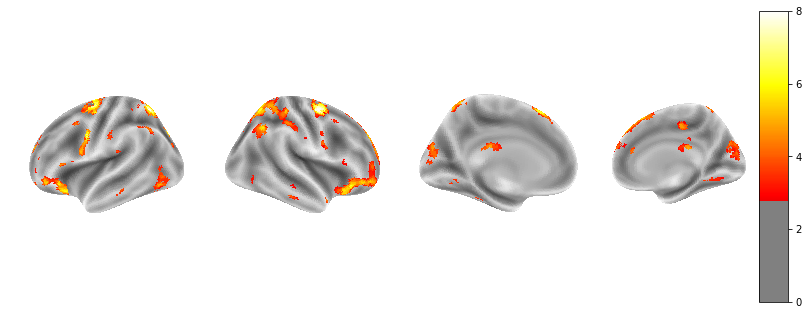

In [94]:


texture_threshold = 0.5

# Binarize the img for groups 1 to 4
overlay_mask = math_img(f'img1 !=0', img1=overlay)

surfaces = [fsaverage.pial_right, fsaverage.pial_left]

# Process each group
textures_mask = {}

textures_mask['right'], textures_mask['left'] = [
        np.where(surface.vol_to_surf(overlay_mask, surf, interpolation='nearest') > texture_threshold, 1, 0)
        for surf in surfaces]



cmap='hot'

# Iterate over each group and plot left & right hemispheres
z_surface = {}
for hemi in ["left", "right"]:
    surface_image = surface.vol_to_surf(
    thresholded_map,
    surf_mesh=fsaverage[f"pial_{hemi}"],
    inner_mesh=fsaverage[f"white_{hemi}"],
    interpolation='nearest')

    # mask the surface image by the textures, which is binary for each cluster
    surface_image_masked = np.where(textures_mask[f'{hemi}'] ==1, surface_image, 0)
    z_surface[hemi] = surface_image_masked

fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(14, 20), subplot_kw={'projection': '3d'})
# make axes tighter
plt.subplots_adjust(wspace=0.01, hspace=0.01)
# Iterate over each group and plot left & right hemispheres

plotting.plot_surf(
    fsaverage.infl_left, z_surface['left'], view='lateral', hemi='left',
    colorbar=False, cmap=cmap, threshold=second_level_threshold, 
    avg_method='median', 
    bg_map=fsaverage.sulc_left, axes=axes[0], darkness=0.8, inflate=True
)

plotting.plot_surf(
    fsaverage.infl_right, z_surface['right'], view='lateral', hemi='right',
    colorbar=False, cmap=cmap, threshold=second_level_threshold, 
    avg_method='median', 
    bg_map=fsaverage.sulc_right, axes=axes[1], darkness=0.8, inflate=True
)

plotting.plot_surf(
    fsaverage.infl_left, z_surface['left'], view='medial', hemi='left',
    colorbar=False, cmap=cmap, threshold=second_level_threshold, 
    avg_method='median', 
    bg_map=fsaverage.sulc_left, axes=axes[2], darkness=0.8, inflate=True
)

plotting.plot_surf(
    fsaverage.infl_right, z_surface[f'right'], view='medial', hemi='right',
    colorbar=True, cmap=cmap, threshold=second_level_threshold, 
    avg_method='median', 
    bg_map=fsaverage.sulc_right, axes=axes[3], darkness=0.8, inflate=True
)



plt.show()


# Figure 2b

In [95]:
# add bar plot per group


import matplotlib.patches


def CreateBarPlotsForClusters(df, df_sem,  title = '', hatches=None, color_list=None):
    # Number of clusters
    import math
    import seaborn as sns
    num_clusters = len(df)

    # Get the global minimum and maximum values across all clusters for uniform y-axis scaling
    y_min = df.min().min() - 0.5
    y_max = df.max().max() + 0.5

    # Create subplots
    if num_clusters < 10:
        n_rows=1
        n_cols = num_clusters
        fig_size = (21, 7)
    else:
        n_rows=4
        n_cols = math.ceil(num_clusters / n_rows)
        fig_size = (21, 14)

    fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=fig_size)
    axes = axes.flatten()

    # Iterate through each cluster and create a bar plot
    if color_list is None:
        # make a color list of grays for each cluster
        color_list = ['gray'] * num_clusters

    # hatch
    if hatches is None:
        hatches = ["xx","++", "//",  "//||", ".", ".||"] 
           
    num_features = len(df.columns)
    for i in range(num_clusters):
        
        # bar plot
        # df.iloc[i].plot(kind='bar', ax=axes[i], color=color_list[i], yerr=df_sem_byvideo.iloc[i], capsize=3, error_kw={'ecolor': 'black', 'linewidth': 1})
        x = np.arange(num_features)
        bars = axes[i].bar(x, df.iloc[i], color=color_list[i], width=0.6,
                           yerr=df_sem.iloc[i], capsize=5, 
                           error_kw={'ecolor': 'black', 'linewidth': 1})
        
        # Add hatches to bars
        for bar, hatch in zip(bars, hatches):
            bar.set_hatch(hatch)
        
        axes[i].set_title(f'Group {i+1}', fontsize=16, fontweight='bold')

        # Only set x-axis label for the bottom-most subplots
        # xtick labels list
        
        if i >= num_clusters - n_cols:  # Last row of subplots
            axes[i].set_xlabel(' ') # remove x-axis label
            axes[i].tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=False)  # Show x-ticks
        else:
            axes[i].set_xlabel('')  # Remove x-axis label if more than one row of subplots
            axes[i].tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)  # Remove x-ticks
       
        axes[i].tick_params(axis='y', which='major', labelsize=14, width=2, length=6)
        # Only set y-axis label for the left-most subplots
        if i % n_cols == 0:  # First column of subplots
            axes[i].set_ylabel('Mean Activation (Z-score)', fontsize=16, fontweight='bold')
        else:
            axes[i].set_ylabel('')  # Remove y-axis label

        # Set uniform y-axis limits
        axes[i].set_ylim([y_min, y_max])
    
        # Remove gridlines
        axes[i].grid(False)

        # Increase axis line width
        axes[i].spines['left'].set_linewidth(2)
        axes[i].spines['bottom'].set_linewidth(2)
        axes[i].spines['top'].set_visible(False)
        axes[i].spines['right'].set_visible(False)
        
    
    # Create legend
    # legend_elements = [plt.Rectangle((0,0),1,1, facecolor='white', edgecolor='black', hatch=h, label=f) 
    #                    for h, f in zip(hatches, df.columns)]
    # fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.02), 
    #            ncol=num_features, title="Features")
    x_labels_list = [f.replace('_',' ') for f in df.columns]
    legend_elements = [matplotlib.patches.Patch(facecolor='white', edgecolor='black', hatch=h, label=f, linewidth=0.5) 
                       for h, f in zip(hatches, x_labels_list)]
    legend = fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.05), 
                        ncol=num_features, title=" ", fontsize=24)
            # Increase axis line width
    
    # If there are any unused subplots, hide them
    for j in range(num_clusters, n_rows * n_cols):
        fig.delaxes(axes[j])
    # Set a global title

    fig.suptitle(title, fontsize=16)
    # Display the plots
    plt.show()
    plt.clf()
    plt.close()



In [96]:
df_brain = df_grouped_transposed.groupby('Cluster').mean()
df_brain.columns = [col.split('video-')[1] for col in df_brain.columns]
df_brain = df_brain.T.reset_index()
df_brain.columns = ['trial', 'Cluster 1', 'Cluster 2', 'Cluster 3']
df_brain['condition'] = df_brain['trial'].str.split('_', expand=True)[1]
# rename condition to Social = agent-dependent, Pattern = agent-independent
df_brain.loc[df_brain['condition']=='Social', 'condition'] = 'Agent Dep.'
df_brain.loc[df_brain['condition']=='Pattern', 'condition'] = 'Agent Indep.'
df_brain['video'] = df_brain['trial'].str.split('_', expand=True)[0]
df_brain['PE'] = df_brain['trial'].str.split('_', expand=True)[2]
df_brain.loc[df_brain['video']=='obs', 'PE'] = 'obs'
# drop video column and name PE column as video
df_brain = df_brain.drop(columns=['video'])
df_brain = df_brain.rename(columns={'PE':'video'})
df_brain

,trial,Cluster 1,Cluster 2,Cluster 3,condition,video
0,obs_Pattern,5.448689,-0.459924,-3.089022,Agent Indep.,obs
1,obs_Pattern,4.817492,0.704062,-2.523084,Agent Indep.,obs
2,obs_Pattern,5.148329,-1.008441,-3.306904,Agent Indep.,obs
3,obs_Pattern,6.147057,0.809380,-2.990769,Agent Indep.,obs
4,obs_Pattern,5.568310,-0.335154,-2.816790,Agent Indep.,obs
...,...,...,...,...,...,...
82,fb_Pattern_PE,1.585073,1.550687,-1.301388,Agent Indep.,PE
83,fb_Pattern_PE,1.705877,1.412697,0.368988,Agent Indep.,PE
84,fb_Pattern_PE,1.874963,2.262336,0.514358,Agent Indep.,PE
85,fb_Pattern_PE,2.970370,2.627306,0.513974,Agent Indep.,PE


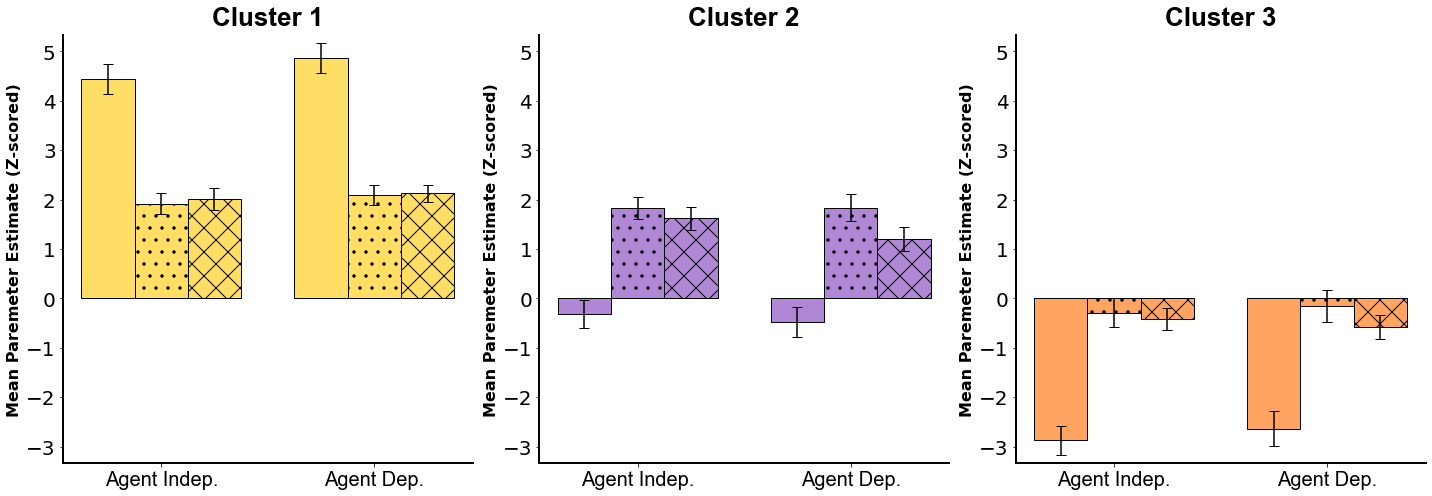

In [97]:


def create_grouped_barplot(data, groups):
    # Set up the figure and axes
    n_cols = 3
    fig, axes = plt.subplots(1, n_cols, figsize=(20,7))
    axes = axes.ravel()
    
    # Define style parameters
    width = 0.25  # Width of bars
    group_colors = ['#FFC800', '#7A3EB1', '#F76800']  # Colors for different groups
    conditions = ['obs', 'Congruent', 'PE']

    # First find the global min and max values across all groups
    all_values = []
    all_sems = []
    for group in groups:
        for cond in conditions:
            for main_cond in data['condition'].unique():
                subset = data[(data['condition'] == main_cond) & (data['video'] == cond)]
                all_values.append(subset[group].mean())
                all_sems.append(subset[group].sem())
    
    # Calculate global y-axis limits
    max_value = max(all_values) + max(all_sems) + 0.1
    min_value = min(all_values) - max(all_sems) - 0.1
    
    for idx, group in enumerate(groups):
        ax = axes[idx]
        base_color = group_colors[idx]
        light_color = lighten_color(base_color, 0.6)  # Create lighter shade
        
        # Get unique conditions
        unique_conditions = data['condition'].unique()
        
        # Calculate positions for bars
        x = np.arange(len(unique_conditions))
        
        # Plot bars for each condition type
        for i, cond in enumerate(conditions):
            # Calculate means and SEMs
            means = []
            sems = []
            for main_cond in unique_conditions:
                subset = data[(data['condition'] == main_cond) & (data['video'] == cond)]
                means.append(subset[group].mean())
                sems.append(subset[group].sem())
            
            # Set bar properties based on condition
            if cond == 'obs':
                color = light_color
                hatch = ''
            elif cond == 'PE':
                color = light_color
                hatch = 'x'
            else:  # congruent
                color = light_color
                hatch = '.'
            
            # Plot bars with error bars
            ax.bar(x + (i-1)*width, means, width, 
                  label=cond,
                  color=color,
                  hatch=hatch,
                  yerr=sems,
                  capsize=5,
                  edgecolor='black',  # Add black outline
                  linewidth=1)
            
            axes[i].set_ylabel('Mean Paremeter Estimate (Z-scored)', fontsize=16, fontweight='bold')
            # # Only set y-axis label for the left-most subplots
            # if i % n_cols == 0:  # First column of subplots
            #     axes[i].set_ylabel('Mean Paremeter Estimate (Z-scored)', fontsize=16, fontweight='bold')
            # else:
            #     axes[i].set_ylabel('')  # Remove y-axis label
            

            # Increase axis line width
            ax.spines['left'].set_linewidth(2)
            ax.spines['bottom'].set_linewidth(2)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            # Set uniform y-axis limits
            ax.set_ylim([min_value, max_value])

        ax.set_title(f'{group}', fontsize=26, pad=10, fontweight='bold', font='Arial')
        ax.set_xticks(x)
        ax.set_xticklabels(unique_conditions, fontsize=40, font='Arial')
        ax.tick_params(axis='both', which='major', labelsize=20)

        

        # # Add grid for better readability
        # ax.grid(True, axis='y', linestyle='--', alpha=0.7)
    
    # Adjust layout
    # add more vertical space between subplots
    fig.tight_layout()
    fig.subplots_adjust(hspace=0.5)
    return fig


groups = ['Cluster 1', 'Cluster 2', 'Cluster 3']
fig = create_grouped_barplot(df_brain, groups)
plt.show()

# Table S1: brain region analysis

In [98]:
cue_cols = [col for col in df_grouped_transposed.columns if 'obs_' in col]
fb_cols = [col for col in df_grouped_transposed.columns if 'fb_' in col]
roi_sub_z_df_cue = df_grouped_transposed[cue_cols]
roi_sub_z_df_fb = df_grouped_transposed[fb_cols]

# average social pattern cue videos such that the df is 3x30
sub_id_list = [col.split('sub-')[1].split("_video")[0] for col in roi_sub_z_df_cue.columns]
sub_id_list = ['sub-' + str(sub_id) for sub_id in sub_id_list]
roi_sub_z_df_cue = roi_sub_z_df_cue.T.reset_index(drop=True)
roi_sub_z_df_cue['sub'] = sub_id_list
roi_sub_z_df_cue = roi_sub_z_df_cue.groupby('sub').mean().T

# average Congruent and PE fb videos such that the df is 3x30
sub_id_list = [col.split('sub-')[1].split("_video")[0] for col in roi_sub_z_df_fb.columns]
sub_id_list = ['sub-' + str(sub_id) for sub_id in sub_id_list]
roi_sub_z_df_fb = roi_sub_z_df_fb.T.reset_index(drop=True)
roi_sub_z_df_fb['sub'] = sub_id_list
roi_sub_z_df_fb = roi_sub_z_df_fb.groupby('sub').mean().T

t_tests = []
for brain_region in df_grouped_transposed.index:
    cue_values = roi_sub_z_df_cue.loc[brain_region].values
    fb_values = roi_sub_z_df_fb.loc[brain_region].values
    
    # Perform the t-test
    t_test_result = pg.ttest(cue_values, fb_values, paired=True)
    t_test_result['brain_region'] = brain_region + 1
    t_tests.append(t_test_result)

ttests_df = pd.concat(t_tests)

ttests_df['p_bon'] = pg.multicomp(ttests_df['p-val'], method='bonferroni')[1]
ttests_df['p_fdr'] = pg.multicomp(ttests_df['p-val'], method='fdr_by')[1]    

In [99]:
# select cue video columns
cue_pattern_cols = [col for col in df_grouped_transposed.columns if 'obs_Pattern' in col]
cue_social_cols = [col for col in df_grouped_transposed.columns if 'obs_Social' in col]
cue_pattern_df = df_grouped_transposed[cue_pattern_cols]
cue_social_df = df_grouped_transposed[cue_social_cols]
# convert to numeric
cue_pattern_df = cue_pattern_df.apply(pd.to_numeric, errors='coerce')
cue_social_df = cue_social_df.apply(pd.to_numeric, errors='coerce')
cue_social_df


sub_video,sub-170_video-obs_Social,sub-179_video-obs_Social,sub-154_video-obs_Social,sub-157_video-obs_Social,sub-158_video-obs_Social,sub-185_video-obs_Social,sub-171_video-obs_Social,sub-147_video-obs_Social,sub-156_video-obs_Social,sub-160_video-obs_Social,sub-174_video-obs_Social,sub-143_video-obs_Social,sub-146_video-obs_Social,sub-166_video-obs_Social,sub-159_video-obs_Social
0,5.045931,6.682375,7.797118,6.540349,5.452795,4.188675,6.371348,3.404287,6.361218,3.559817,5.146898,4.987195,7.618598,7.815550,4.696637
1,7.154190,8.537351,10.669686,6.223946,4.939721,6.511177,5.853852,3.654717,9.120391,4.636383,5.710178,5.839864,8.611093,9.225446,7.704607
2,8.007138,9.806768,8.474828,7.630893,7.606012,5.748128,6.469083,4.582706,9.081199,4.873669,7.749585,4.294296,9.778295,9.683948,7.461681
3,-3.916740,-1.221961,-3.244114,-1.796825,-1.899363,-2.948927,-2.524760,-0.779739,-1.246761,-0.322005,0.182714,-1.645860,-4.016759,-1.363203,-1.035313
4,6.391356,7.416356,7.730596,7.373782,6.642783,4.565044,4.773780,3.698781,7.249004,5.320753,4.445374,3.881119,6.316110,6.403126,6.564799
5,-0.482114,-0.514221,-1.489789,-0.232958,0.529448,-3.598112,-1.709126,0.186932,0.538657,-2.353848,-0.145990,0.808652,-0.948367,0.620435,-1.580235
6,8.644662,5.904916,8.029304,6.259707,5.166198,3.855653,6.263055,2.927282,7.702814,2.405773,7.262747,8.253583,6.387688,8.437875,5.443797
7,-2.332264,0.564850,-2.400841,-0.386308,-2.296623,-2.168710,-2.580724,-0.025578,-0.455948,0.081160,1.150461,-0.717412,-1.906966,-1.071768,-0.835389
8,-2.368110,0.952640,-2.296693,-1.915907,-1.581999,-3.994013,-4.186053,-1.205709,-1.723880,-0.154470,-0.332161,-1.634025,-2.273273,-0.999050,-1.850170
9,4.602807,7.244228,5.886056,5.856033,6.584841,3.692963,4.884551,4.257018,4.641357,4.168439,5.610566,5.442741,8.719969,9.937315,8.421054


In [100]:
# for each cluster, test whether there is a significant difference between the pattern and social conditions

condition_tests = []
for cluster in df_grouped_transposed.index:
    pattern_values = cue_pattern_df.loc[cluster].values
    social_values = cue_social_df.loc[cluster].values
    
    # Perform the t-test
    t_test_result = pg.ttest(pattern_values, social_values, paired=True)
    condition_tests.append(t_test_result)
condition_tests_df = pd.concat(condition_tests)
condition_tests_df['p_bon'] = pg.multicomp(condition_tests_df['p-val'], method='bonferroni')[1]
condition_tests_df['p_fdr'] = pg.multicomp(condition_tests_df['p-val'], method='fdr_by')[1]
condition_tests_df['brain_region'] = df_grouped_transposed.index +1
condition_tests_df

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power,p_bon,p_fdr,brain_region
T-test,-1.283635,14,two-sided,0.220109,"[-0.98, 0.25]",0.251810,0.524,0.148832,1.000000,1.0,1
T-test,-1.037962,14,two-sided,0.316883,"[-1.09, 0.38]",0.207981,0.416,0.116775,1.000000,1.0,2
T-test,-1.979640,14,two-sided,0.067753,"[-1.86, 0.07]",0.533659,1.218,0.485920,1.000000,1.0,3
T-test,-0.271019,14,two-sided,0.790332,"[-0.68, 0.53]",0.073518,0.271,0.058129,1.000000,1.0,4
T-test,-2.307176,14,two-sided,0.036845,"[-1.23, -0.04]",0.484873,1.949,0.416609,1.000000,1.0,5
T-test,0.267505,14,two-sided,0.792981,"[-0.4, 0.51]",0.043147,0.271,0.052792,1.000000,1.0,6
T-test,-0.301691,14,two-sided,0.767322,"[-0.75, 0.56]",0.044515,0.273,0.052972,1.000000,1.0,7
T-test,0.642518,14,two-sided,0.530919,"[-0.44, 0.82]",0.174013,0.314,0.096386,1.000000,1.0,8
T-test,-0.626028,14,two-sided,0.541370,"[-0.83, 0.46]",0.157694,0.312,0.087958,1.000000,1.0,9
T-test,-1.609226,14,two-sided,0.129877,"[-1.71, 0.24]",0.380495,0.754,0.279195,1.000000,1.0,10


In [101]:
fb_cols = [col for col in df_grouped_transposed.columns if 'fb_' in col]

roi_fb_df = df_grouped_transposed[fb_cols]
# to numeric
roi_fb_df = roi_fb_df.apply(pd.to_numeric, errors='coerce')
roi_fb_df


sub_video,sub-170_video-fb_Social_Congruent,sub-179_video-fb_Social_Congruent,sub-154_video-fb_Social_Congruent,sub-157_video-fb_Social_Congruent,sub-158_video-fb_Social_Congruent,sub-185_video-fb_Social_Congruent,sub-147_video-fb_Social_Congruent,sub-156_video-fb_Social_Congruent,sub-160_video-fb_Social_Congruent,sub-174_video-fb_Social_Congruent,...,sub-158_video-fb_Pattern_PE,sub-185_video-fb_Pattern_PE,sub-171_video-fb_Pattern_PE,sub-147_video-fb_Pattern_PE,sub-156_video-fb_Pattern_PE,sub-160_video-fb_Pattern_PE,sub-174_video-fb_Pattern_PE,sub-146_video-fb_Pattern_PE,sub-166_video-fb_Pattern_PE,sub-159_video-fb_Pattern_PE
0,4.204861,2.592062,3.201991,2.460148,1.740331,-0.059359,0.077869,2.284955,3.177811,2.304767,...,2.177144,1.587517,2.844723,0.651365,2.454221,2.880732,1.202095,1.503320,3.405159,0.302015
1,4.530407,4.052960,5.406987,2.988632,1.656266,2.850809,-0.381836,3.562127,3.965152,2.240741,...,2.776832,4.432408,1.998539,0.604179,4.227929,3.013988,1.614440,2.896966,4.301340,3.406251
2,3.190000,6.957704,5.220005,2.438326,3.601356,3.329316,0.856671,2.382023,4.527364,2.219107,...,4.257420,4.673098,2.396903,2.093139,3.924118,3.942396,3.058489,2.447344,2.884378,3.699815
3,-0.493920,1.499360,-0.037240,0.159783,1.720159,0.402143,-0.018784,1.850725,-0.358292,2.652281,...,1.383738,1.347931,-0.541831,-0.196065,0.711077,0.998445,0.620818,1.282644,0.785169,0.796347
4,2.942779,4.193437,4.358398,2.182740,2.164440,0.927211,0.540351,1.443362,4.151199,0.737946,...,2.662116,2.825494,2.223022,0.995551,2.728287,3.227570,0.580932,1.250439,2.442722,1.774700
5,2.952725,1.108457,1.148308,1.755075,3.561259,1.736876,0.811776,2.683367,-1.615449,2.703931,...,2.176561,1.398855,-0.241285,0.753711,2.586975,0.074171,1.058546,3.068703,2.284129,2.212729
6,6.130437,3.032711,3.159218,3.231567,3.176098,2.472199,1.834733,2.974327,2.897603,2.560544,...,3.604172,3.565478,2.629339,0.076590,2.122654,2.295750,2.097574,3.213801,4.379158,1.742028
7,1.184372,2.650379,-0.052319,1.210266,2.672542,1.499376,0.467667,2.867874,0.504924,2.058190,...,2.605324,2.759253,-0.324672,0.927683,1.070010,1.253198,0.877912,1.764656,2.492327,0.624628
8,1.432082,2.751730,-0.344424,0.595597,2.773682,-0.101750,-1.078564,0.959596,1.273032,2.695799,...,1.689619,0.815784,-0.508289,-1.474003,0.249166,1.856144,-0.971012,0.758076,1.076832,-0.873020
9,2.273755,4.861850,2.111543,2.324341,4.151195,1.901248,0.363058,0.611884,4.245358,2.867434,...,4.196037,2.870602,0.073178,1.813072,1.762959,3.262106,4.264329,2.117678,4.770419,2.877884


In [102]:

sub_id_list = [col.split('sub-')[1].split("_video")[0] for col in roi_fb_df.columns]
sub_id_list = ['sub-' + str(sub_id) for sub_id in sub_id_list]
roi_fb_df.columns = [col.split('video-')[1] for col in roi_fb_df.columns]
roi_df_groupd = roi_fb_df.T.reset_index()
roi_df_groupd.columns = ['trial'] + [f"brain_region_{i}" for i in range(1, len(roi_fb_df)+1)]
roi_df_groupd['condition'] = roi_df_groupd['trial'].str.split('_', expand=True)[1]
# rename condition to Social = agent-dependent, Pattern = agent-independent
roi_df_groupd.loc[roi_df_groupd['condition']=='Social', 'condition'] = 'agent-dependent'
roi_df_groupd.loc[roi_df_groupd['condition']=='Pattern', 'condition'] = 'agent-independent'
roi_df_groupd['feedback_type'] = roi_df_groupd['trial'].str.split('_', expand=True)[0]
roi_df_groupd['PE'] = roi_df_groupd['trial'].str.split('_', expand=True)[2]
roi_df_groupd.loc[roi_df_groupd['feedback_type']=='obs', 'PE'] = 'obs'
# drop video column and name PE column as video
roi_df_groupd = roi_df_groupd.drop(columns=['feedback_type'])
roi_df_groupd = roi_df_groupd.rename(columns={'PE':'feedback_type'})
roi_df_groupd['subject']=sub_id_list
roi_df_groupd

,trial,brain_region_1,brain_region_2,brain_region_3,brain_region_4,brain_region_5,brain_region_6,brain_region_7,brain_region_8,brain_region_9,...,brain_region_27,brain_region_28,brain_region_29,brain_region_30,brain_region_31,brain_region_32,brain_region_33,condition,feedback_type,subject
0,fb_Social_Congruent,4.204861,4.530407,3.190000,-0.493920,2.942779,2.952725,6.130437,1.184372,1.432082,...,-0.727787,0.073028,1.706122,3.764259,2.271492,2.045682,5.281945,agent-dependent,Congruent,sub-170
1,fb_Social_Congruent,2.592062,4.052960,6.957704,1.499360,4.193437,1.108457,3.032711,2.650379,2.751730,...,-2.419675,0.521962,1.180237,3.306768,-0.055434,9.427439,3.606230,agent-dependent,Congruent,sub-179
2,fb_Social_Congruent,3.201991,5.406987,5.220005,-0.037240,4.358398,1.148308,3.159218,-0.052319,-0.344424,...,0.120684,-0.173456,0.186964,0.393512,-0.180088,4.476018,4.646147,agent-dependent,Congruent,sub-154
3,fb_Social_Congruent,2.460148,2.988632,2.438326,0.159783,2.182740,1.755075,3.231567,1.210266,0.595597,...,-0.323295,0.651250,1.270214,1.706746,0.166732,3.539589,3.193685,agent-dependent,Congruent,sub-157
4,fb_Social_Congruent,1.740331,1.656266,3.601356,1.720159,2.164440,3.561259,3.176098,2.672542,2.773682,...,1.372681,0.510911,3.031521,4.418958,2.393071,6.586103,0.452857,agent-dependent,Congruent,sub-158
5,fb_Social_Congruent,-0.059359,2.850809,3.329316,0.402143,0.927211,1.736876,2.472199,1.499376,-0.101750,...,-3.202933,0.144598,2.374806,3.679216,2.917175,5.159907,2.375045,agent-dependent,Congruent,sub-185
6,fb_Social_Congruent,0.077869,-0.381836,0.856671,-0.018784,0.540351,0.811776,1.834733,0.467667,-1.078564,...,-1.953102,-1.175505,-0.214707,0.117295,-0.247922,1.246949,-0.078517,agent-dependent,Congruent,sub-147
7,fb_Social_Congruent,2.284955,3.562127,2.382023,1.850725,1.443362,2.683367,2.974327,2.867874,0.959596,...,-0.389043,-0.579579,1.458093,2.923834,2.366791,2.640212,1.554330,agent-dependent,Congruent,sub-156
8,fb_Social_Congruent,3.177811,3.965152,4.527364,-0.358292,4.151199,-1.615449,2.897603,0.504924,1.273032,...,-5.260246,-0.314499,-0.088611,2.978559,1.862572,4.281187,0.476363,agent-dependent,Congruent,sub-160
9,fb_Social_Congruent,2.304767,2.240741,2.219107,2.652281,0.737946,2.703931,2.560544,2.058190,2.695799,...,2.396209,-0.417966,2.719430,4.088301,0.348279,4.154781,0.905519,agent-dependent,Congruent,sub-174


In [103]:
import pingouin as pg
anova_list = []
for i in range(1, len(roi_fb_df)+1):
    aov = pg.rm_anova(dv=f'brain_region_{i}', within=['condition', 'feedback_type'],
                    subject='subject', data=roi_df_groupd, effsize='n2')
    aov['brain_region'] = i
   
    anova_list.append(aov)
anova_df = pd.concat(anova_list)
anova_df['p_bon'] = pg.multicomp(anova_df['p-unc'], method='bonferroni')[1]
anova_df['p_fdr'] = pg.multicomp(anova_df['p-unc'], method='fdr_by')[1]

In [104]:
anova_df[anova_df['p-unc'] < 0.05].sort_values('brain_region')

,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,n2,eps,brain_region,p_bon,p_fdr
2,condition * feedback_type,6.850110,1,11,6.850110,19.000175,0.001138,0.001138,0.065522,1.0,3,0.112696,0.194490
2,condition * feedback_type,1.020243,1,11,1.020243,6.963250,0.023043,0.023043,0.032390,1.0,4,1.000000,1.000000
1,feedback_type,3.318455,1,11,3.318455,8.200272,0.015417,0.015417,0.051918,1.0,6,1.000000,1.000000
1,feedback_type,4.028235,1,11,4.028235,5.336420,0.041294,0.041294,0.075964,1.0,15,1.000000,1.000000
2,condition * feedback_type,2.938350,1,11,2.938350,7.742782,0.017821,0.017821,0.049252,1.0,16,1.000000,1.000000
2,condition * feedback_type,2.672150,1,11,2.672150,5.064449,0.045855,0.045855,0.033650,1.0,17,1.000000,1.000000
1,feedback_type,5.488727,1,11,5.488727,6.100443,0.031127,0.031127,0.043094,1.0,21,1.000000,1.000000
0,condition,3.807002,1,11,3.807002,5.040227,0.046290,0.046290,0.050505,1.0,23,1.000000,1.000000
1,feedback_type,6.142869,1,11,6.142869,10.690744,0.007470,0.007470,0.081494,1.0,23,0.739486,0.824006
1,feedback_type,4.389288,1,11,4.389288,5.827034,0.034375,0.034375,0.057691,1.0,26,1.000000,1.000000


In [105]:
anova_df.to_csv(f'anova_results.csv', index=False)

In [106]:
anova_df[(anova_df['p-unc'] < 0.05) & (anova_df['Source'] == 'condition * feedback_type')].sort_values('brain_region')

,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,n2,eps,brain_region,p_bon,p_fdr
2,condition * feedback_type,6.850110,1,11,6.850110,19.000175,0.001138,0.001138,0.065522,1.0,3,0.112696,0.194490
2,condition * feedback_type,1.020243,1,11,1.020243,6.963250,0.023043,0.023043,0.032390,1.0,4,1.000000,1.000000
2,condition * feedback_type,2.938350,1,11,2.938350,7.742782,0.017821,0.017821,0.049252,1.0,16,1.000000,1.000000
2,condition * feedback_type,2.672150,1,11,2.672150,5.064449,0.045855,0.045855,0.033650,1.0,17,1.000000,1.000000
2,condition * feedback_type,16.145978,1,11,16.145978,83.776341,0.000002,0.000002,0.379321,1.0,28,0.000176,0.000911


In [107]:

# make simple effects:
AD_t_test_results = []
# for roi in range(1, 32):
for roi in range(1, 32):
    roi_col = roi_df_groupd[f'brain_region_{roi}']
    # compare across conditions:
    # Agent-dependent incongruency effects: AD I > AD C
    ad_incongruency = roi_col[(roi_df_groupd['condition'] == 'agent-dependent') & (roi_df_groupd['feedback_type'] == 'PE')].values.astype(np.float64)
    ad_congruency = roi_col[(roi_df_groupd['condition'] == 'agent-dependent') & (roi_df_groupd['feedback_type'] == 'Congruent')].values.astype(np.float64)
    t_test_result = pg.ttest(ad_incongruency, ad_congruency, alternative='greater')
    t_test_result['roi'] = f'brain_region_{roi}' 
    t_test_result['simple_effect']= 'AD I > C'
    AD_t_test_results.append(t_test_result)


    t_test_result = pg.ttest(ad_congruency, ad_incongruency, alternative='greater')
    t_test_result['roi'] = f'brain_region_{roi}'
    t_test_result['simple_effect']= 'AD C > I'
    AD_t_test_results.append(t_test_result)


    
AI_t_test_results = []
for roi in range(1, 32):
    roi_col = roi_df_groupd[f'brain_region_{roi}']
    # compare across conditions:
    # Agent-independent incongruency effects: AI I > AI C
    ai_incongruency = roi_col[(roi_df_groupd['condition'] == 'agent-independent') & (roi_df_groupd['feedback_type'] == 'PE')].values.astype(np.float64)
    ai_congruency = roi_col[(roi_df_groupd['condition'] == 'agent-independent') & (roi_df_groupd['feedback_type'] == 'Congruent')].values.astype(np.float64)
    t_test_result = pg.ttest(ai_incongruency, ai_congruency, alternative='greater')
    t_test_result['roi'] = f'brain_region_{roi}'
    t_test_result['simple_effect']= 'AI I > C'
    AI_t_test_results.append(t_test_result)

    t_test_result = pg.ttest(ai_congruency, ai_incongruency, alternative='greater')
    t_test_result['roi'] = f'brain_region_{roi}'
    t_test_result['simple_effect']= 'AI C > I'
    AI_t_test_results.append(t_test_result)


AD_t_test_df = pd.concat(AD_t_test_results)
AI_t_test_df = pd.concat(AI_t_test_results)

# add p_bon and p_fdr columns
AD_t_test_df['p_bon'] = pg.multicomp(AD_t_test_df['p-val'], method='bonferroni')[1]
AD_t_test_df['p_fdr'] = pg.multicomp(AD_t_test_df['p-val'], method='fdr_by')[1]
AI_t_test_df['p_bon'] = pg.multicomp(AI_t_test_df['p-val'], method='bonferroni')[1]
AI_t_test_df['p_fdr'] = pg.multicomp(AI_t_test_df['p-val'], method='fdr_by')[1]



In [108]:
new_to_old_roi = dict(enumerate(brain_regions, start=1))
old_to_new_roi = {v: k for k, v in new_to_old_roi.items()}
print(old_to_new_roi)

# plot brain region 1, 13, 14, 15, 28
AI_t_test_df['new_roi'] = AI_t_test_df['roi'].apply(lambda x: old_to_new_roi[x])
AD_t_test_df['new_roi'] = AD_t_test_df['roi'].apply(lambda x: old_to_new_roi[x])

AI_t_test_df[AI_t_test_df['p-val'] < 0.05].sort_values('simple_effect')

{'brain_region_1': 1, 'brain_region_10': 2, 'brain_region_11': 3, 'brain_region_14': 4, 'brain_region_15': 5, 'brain_region_16': 6, 'brain_region_17': 7, 'brain_region_19': 8, 'brain_region_2': 9, 'brain_region_25': 10, 'brain_region_28': 11, 'brain_region_3': 12, 'brain_region_32': 13, 'brain_region_33': 14, 'brain_region_5': 15, 'brain_region_7': 16, 'brain_region_18': 17, 'brain_region_22': 18, 'brain_region_23': 19, 'brain_region_24': 20, 'brain_region_29': 21, 'brain_region_30': 22, 'brain_region_31': 23, 'brain_region_6': 24, 'brain_region_8': 25, 'brain_region_12': 26, 'brain_region_13': 27, 'brain_region_20': 28, 'brain_region_21': 29, 'brain_region_26': 30, 'brain_region_27': 31, 'brain_region_4': 32, 'brain_region_9': 33}


,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power,roi,simple_effect,p_bon,p_fdr,new_roi
T-test,1.725315,24.131984,greater,0.048628,"[0.01, inf]",0.647507,2.081,0.521411,brain_region_29,AI C > I,1.000000,1.000000,21
T-test,3.848791,26.104475,greater,0.000345,"[0.67, inf]",1.436107,86.535,0.983010,brain_region_28,AI I > C,0.021359,0.100654,11


In [109]:
AD_t_test_df[AD_t_test_df['p-val'] < 0.05].sort_values('simple_effect')

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power,roi,simple_effect,p_bon,p_fdr,new_roi
T-test,2.169040,24.314541,greater,0.020038,"[0.16, inf]",0.829005,3.8,0.686303,brain_region_8,AD C > I,1.000000,1.000000,25
T-test,1.936534,24.668769,greater,0.032169,"[0.1, inf]",0.738414,2.741,0.599764,brain_region_9,AD C > I,1.000000,1.000000,33
T-test,2.167118,23.375026,greater,0.020326,"[0.14, inf]",0.832807,3.79,0.689757,brain_region_14,AD C > I,1.000000,1.000000,4
T-test,2.403899,25.997902,greater,0.011823,"[0.28, inf]",0.900416,5.445,0.748182,brain_region_23,AD C > I,0.732997,1.000000,19
T-test,3.534040,23.778836,greater,0.000855,"[0.49, inf]",1.296096,43.132,0.953959,brain_region_28,AD C > I,0.053028,0.249889,11
T-test,2.239094,22.824660,greater,0.017597,"[0.2, inf]",0.862969,4.218,0.716549,brain_region_29,AD C > I,1.000000,1.000000,21


In [110]:
AD_t_test_df

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power,roi,simple_effect,p_bon,p_fdr,new_roi
T-test,-0.244513,20.027589,greater,0.595340,"[-0.8, inf]",0.095518,0.724,0.029348,brain_region_1,AD I > C,1.0,1.0,1
T-test,0.244513,20.027589,greater,0.404660,"[-0.6, inf]",0.095518,0.724,0.080865,brain_region_1,AD C > I,1.0,1.0,1
T-test,0.264541,22.903199,greater,0.396865,"[-0.73, inf]",0.101915,0.727,0.083359,brain_region_2,AD I > C,1.0,1.0,9
T-test,-0.264541,22.903199,greater,0.603135,"[-1.0, inf]",0.101915,0.727,0.028266,brain_region_2,AD C > I,1.0,1.0,9
T-test,1.544621,25.611941,greater,0.067353,"[-0.1, inf]",0.584192,1.697,0.442980,brain_region_3,AD I > C,1.0,1.0,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...
T-test,2.239094,22.824660,greater,0.017597,"[0.2, inf]",0.862969,4.218,0.716549,brain_region_29,AD C > I,1.0,1.0,21
T-test,-1.438592,25.160531,greater,0.918705,"[-1.98, inf]",0.532175,0.66,0.001290,brain_region_30,AD I > C,1.0,1.0,22
T-test,1.438592,25.160531,greater,0.081295,"[-0.17, inf]",0.532175,1.516,0.390869,brain_region_30,AD C > I,1.0,1.0,22
T-test,-1.484978,24.895498,greater,0.924949,"[-1.82, inf]",0.548249,0.628,0.001125,brain_region_31,AD I > C,1.0,1.0,23


# Figure S9

/Users/yiyuwang/anaconda3/envs/neuroimaging_env/lib/python3.7/site-packages/numpy/ma/core.py:2830: UserWarning: Warning: converting a masked element to nan.
  order=order, subok=True, ndmin=ndmin)


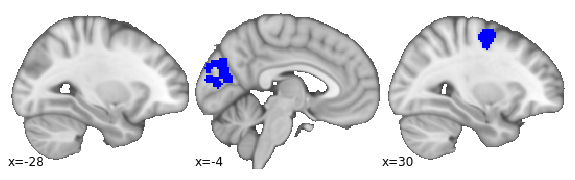

In [111]:
from matplotlib.colors import ListedColormap

# Step 1: Select and remap ROIs
brain_region_list = [1, 13, 14] # 15 = cerebellum, 11 = brain stem
roi_colors = {}

# Assign labels:
# Blue group: label 1 and 2
# Red group: label 3, 4, 5
label_order = {
    1: 1,  # blue
    13: 2, # red
    14: 3  # red
}

# Create remapped list with labels 1–5
label_mapping = {orig: new for orig, new in label_order.items()}

# Map to original string ROI names if needed
brain_region_list_str = [new_to_old_roi[region] for region in brain_region_list]

# Convert to old_label integers again
brain_region_list_int = [int(r.split('brain_region_')[1]) for r in brain_region_list_str]

# Step 2: Apply remapping
roi_map = new_label_map
remapped_array = np.zeros_like(roi_map.get_fdata())

for orig, new in label_mapping.items():
    remapped_array[roi_map.get_fdata() == orig] = new

selected_roi_map = new_img_like(roi_map, remapped_array)

# Step 3: Create a custom color map (label 1–2: blue, label 3–5: red)
custom_cmap = ListedColormap([
    'blue',  # label 1 (ROI 1)
    'red',   # label 4 (ROI 13)
    'red'    # label 5 (ROI 14)
])

# Step 4: Plot
bg_img = 'Data/MNI152_T1_1mm_brain.nii.gz'
plotting.plot_roi(
    selected_roi_map,
    dim=-0.08,
    colorbar=False,
    draw_cross=False,
    cmap=custom_cmap,
    display_mode='x',
    cut_coords=[-28, -4, 30],
    vmax=5,
    black_bg=False,
    bg_img=bg_img,
    alpha=1
)

Reorganized region names: ['brain_region_20']
Original ROI names: [54    20
Name: roi_name, dtype: object]
Original label numbers: [20]
Remapped unique values: [0. 1.]


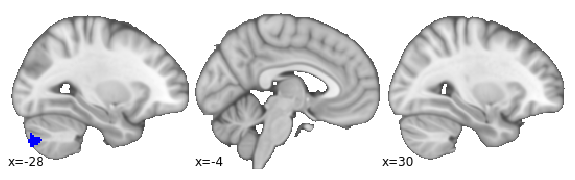

In [112]:

brain_region_list = [28]

# convert to region id in the cluster map
brain_region_list = [new_to_old_roi[region] for region in brain_region_list]
print("Reorganized region names:", brain_region_list)

# Get old region names (for info only)
old_brain_regions = [roi_name_df.loc[roi_name_df['brain_region'] == f'{r}', 'roi_name'] for r in brain_region_list]
print("Original ROI names:", old_brain_regions)


brain_region_list = [int(r.split('brain_region_')[1]) for r in brain_region_list]
print("Original label numbers:", brain_region_list)

# Create remapped label: region 28 → label 1
label_mapping = {brain_region_list[0]: 1}

roi_map = new_label_map
remapped_array = np.zeros_like(roi_map.get_fdata())

for old_label, new_label in label_mapping.items():
    remapped_array[roi_map.get_fdata() == old_label] = new_label

selected_roi_map = new_img_like(roi_map, remapped_array)
print("Remapped unique values:", np.unique(selected_roi_map.get_fdata()))

# Step 6: Plot with custom colormap (label 1 = blue)
bg_img = 'Data/MNI152_T1_1mm_brain.nii.gz'
custom_cmap = ListedColormap(['blue'])

plotting.plot_roi(
    selected_roi_map,
    dim=-0.08,
    colorbar=False,
    draw_cross=False,
    cmap=custom_cmap,
    display_mode='x',
    cut_coords=[-28, -4, 30],
    vmax=1,
    black_bg=False,
    bg_img=bg_img,
    alpha=1,
)


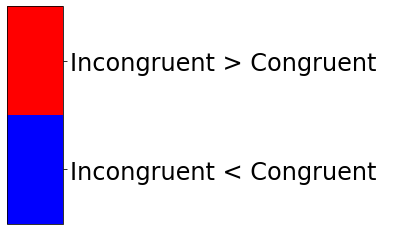

In [113]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm

# Define red (top) and blue (bottom)
cmap = ListedColormap(['blue', 'red'])  # Blue is label 1, Red is label 2
bounds = [0.5, 1.5, 2.5]  # Boundaries between colors
norm = BoundaryNorm(bounds, cmap.N)

# Create colorbar
fig, ax = plt.subplots(figsize=(1, 4))  # Tall and narrow figure
cb = plt.colorbar(
    plt.cm.ScalarMappable(cmap=cmap, norm=norm),
    cax=ax,
    ticks=[1, 2],
    orientation='vertical',
    shrink=0.2,  # Adjust height
)

cb.ax.set_yticklabels(['Incongruent < Congruent', 'Incongruent > Congruent'], fontsize=24)  # Custom labels
cb.set_label(' ')
cb.ax.tick_params(labelsize=24)

plt.show()


# Figure 5

Reorganized region names: ['brain_region_1', 'brain_region_32', 'brain_region_33', 'brain_region_5', 'brain_region_20']
Original ROI names: [0    1
Name: roi_name, dtype: object, 82    32
Name: roi_name, dtype: object, 83    33
Name: roi_name, dtype: object, 12    5
Name: roi_name, dtype: object, 54    20
Name: roi_name, dtype: object]
Original label numbers: [1, 32, 33, 5, 20]
Remapped unique values: [0. 1. 2. 3. 4. 5.]


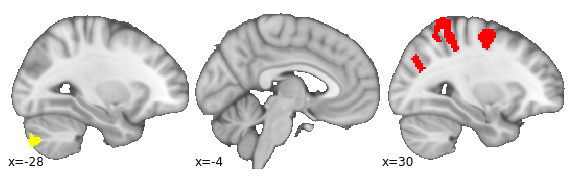

In [114]:
from matplotlib.colors import ListedColormap

# Step 1: Select and remap ROIs
brain_region_list = [1, 13, 14, 15, 28]

roi_colors = {}


# convert to region id in the cluster map
brain_region_list = [new_to_old_roi[region] for region in brain_region_list]
print("Reorganized region names:", brain_region_list)

# Get old region names (for info only)
old_brain_regions = [roi_name_df.loc[roi_name_df['brain_region'] == f'{r}', 'roi_name'] for r in brain_region_list]
print("Original ROI names:", old_brain_regions)


brain_region_list = [int(r.split('brain_region_')[1]) for r in brain_region_list]
print("Original label numbers:", brain_region_list)

# Create remapped label: region 28 → label 1
label_mapping = {brain_region_list[0]: 1, 
                 brain_region_list[1]: 2,
                 brain_region_list[2]: 3,
                 brain_region_list[3]: 4,
                 brain_region_list[4]: 5}

roi_map = new_label_map
remapped_array = np.zeros_like(roi_map.get_fdata())

for old_label, new_label in label_mapping.items():
    remapped_array[roi_map.get_fdata() == old_label] = new_label

selected_roi_map = new_img_like(roi_map, remapped_array)
print("Remapped unique values:", np.unique(selected_roi_map.get_fdata()))

# Step 6: Plot with custom colormap (label 1 = blue)
bg_img = 'Data/MNI152_T1_1mm_brain.nii.gz'
custom_cmap = ListedColormap(['red','red', 'red', 'red', 'yellow'])  # Red for labels 2-4, Blue for labels 1 and 5

plotting.plot_roi(
    selected_roi_map,
    dim=-0.08,
    colorbar=False,
    draw_cross=False,
    cmap=custom_cmap,
    display_mode='x',
    cut_coords=[-28, -4, 30],
    vmax=5,
    black_bg=False,
    bg_img=bg_img,
    alpha=1,
)


['brain_region_1', 'brain_region_32', 'brain_region_33', 'brain_region_5', 'brain_region_20']
[0    1
Name: roi_name, dtype: object, 82    32
Name: roi_name, dtype: object, 83    33
Name: roi_name, dtype: object, 12    5
Name: roi_name, dtype: object, 54    20
Name: roi_name, dtype: object]
[1, 32, 33, 5, 20]
[0. 1. 2. 3. 4. 5.]


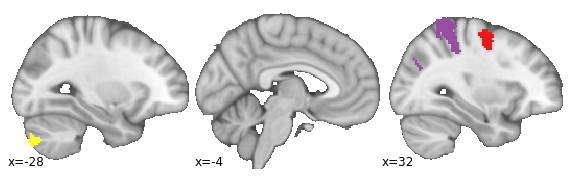

In [115]:
# plot brain region 1, 13, 14, 15, 28




brain_region_list = [1, 13, 14, 15, 28]
# use the mapping to get the reorganized brain region list
brain_region_list = [new_to_old_roi[region] for region in brain_region_list]
print(brain_region_list)
old_brain_regions = [roi_name_df.loc[roi_name_df['brain_region']==f'{r}', 'roi_name'] for r in brain_region_list]
print(old_brain_regions)

brain_region_list = [int(r.split('brain_region_')[1]) for r in brain_region_list]
print(brain_region_list)

roi_map = new_label_map


# # Create a mapping: old label → new label
label_mapping = {old: new for new, old in enumerate(brain_region_list, start=1)}


# Apply the mapping to the array
remapped_array = np.zeros_like(roi_map.get_fdata())
for old_label, new_label in label_mapping.items():
    remapped_array[roi_map.get_fdata() == old_label] = new_label


selected_roi_map = new_img_like(roi_map, remapped_array)
print(np.unique(selected_roi_map.get_fdata()))


bg_img = 'Data/MNI152_T1_1mm_brain.nii.gz'
# bg_img = 'Data/MNI152_T1_0.5mm_brain.nii.gz'
plotting.plot_roi(selected_roi_map, dim=-0.08, colorbar=False, draw_cross=False, cmap='Set1', display_mode='x', cut_coords=[-28, -4, 32], vmax=8, black_bg=False, bg_img = bg_img, alpha = 1)

In [116]:
nib.save(selected_roi_map, f'{second_level_res_dir}selected_roi_map.nii.gz')